<h1 align="center"> 👶 Healthcare Premium Prediction — Young Population Model</h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

## Objective
To build a machine learning model specifically for younger individuals (age ≤ 25) 
to improve prediction accuracy by leveraging more homogeneous data.

## Background
The baseline model showed high prediction errors (~30% predictions >10% error).

To address this, the dataset was segmented based on age.

This notebook focuses on the young population (≤ 25 years).

## Dataset Description

This dataset contains only individuals aged ≤ 25.

Characteristics:
- Lower premium values
- Lower variance
- Simpler risk patterns

This makes it easier for models to learn relationships.

In [2]:
df=pd.read_excel("premiums_young.xlsx")
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [3]:
df.shape

(20096, 13)

In [4]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [5]:
df.columns=df.columns.str.replace(" ","_").str.lower()

In [6]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


<h2 align="center">🧹 Data Cleaning</h3>

### 1.Handling NA Values

In [7]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

if we consider the overall size of the dataset, these na values arent many. So the best thing to do is discard those rows. 

In [8]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### 2. Duplicate Records

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

### 3. Invalid Values

In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [12]:
df[df.number_of_dependants<0].shape

(22, 13)

In [13]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([-3, -1], dtype=int64)

This would have occured probably because there was a bug in the data collection script. Instead of 1 and 3, it would have been saved -1 and -3.

In [14]:
df["number_of_dependants"]=abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

In [15]:
numeric_columns=df.select_dtypes(["float64","int64"]).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

### 📊 Outlier Treatment

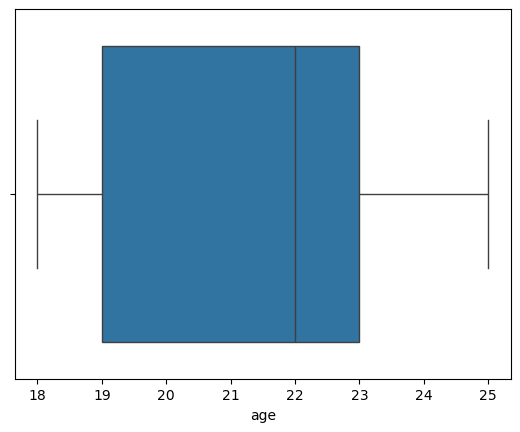

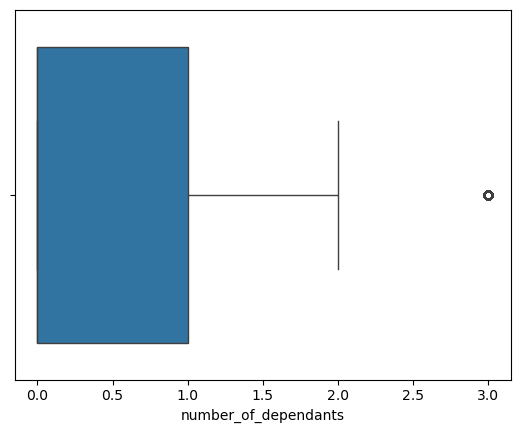

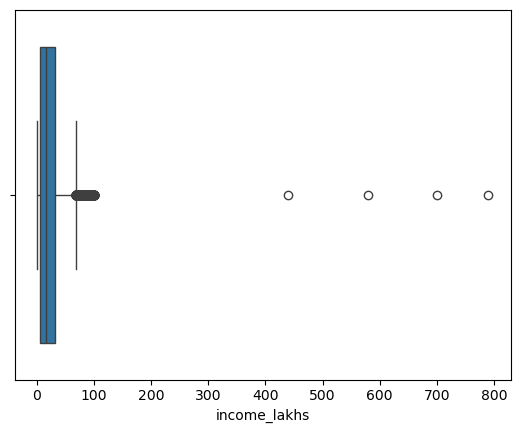

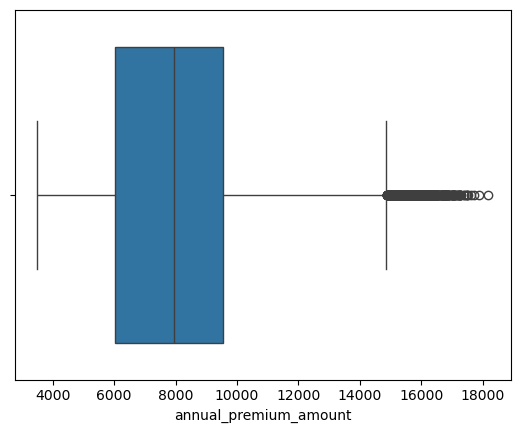

In [16]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

we dont have to treat outliers everytime. sometimes we can leave as it is because depending on domain knowledge we can keep it as well.

##### age

In [17]:
df[df.age>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount


In [18]:
df1=df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


##### Income

In [22]:
quantile_threshold=df1.income_lakhs.quantile(0.999)
quantile_threshold

100.0

In [23]:
df1[df1.income_lakhs>quantile_threshold].shape

(4, 13)

In [24]:
df2=df1[df1.income_lakhs<=quantile_threshold].copy()

In [25]:
df2.shape

(20086, 13)

### Numeric Columns Analysis

#### Univariate Analysis

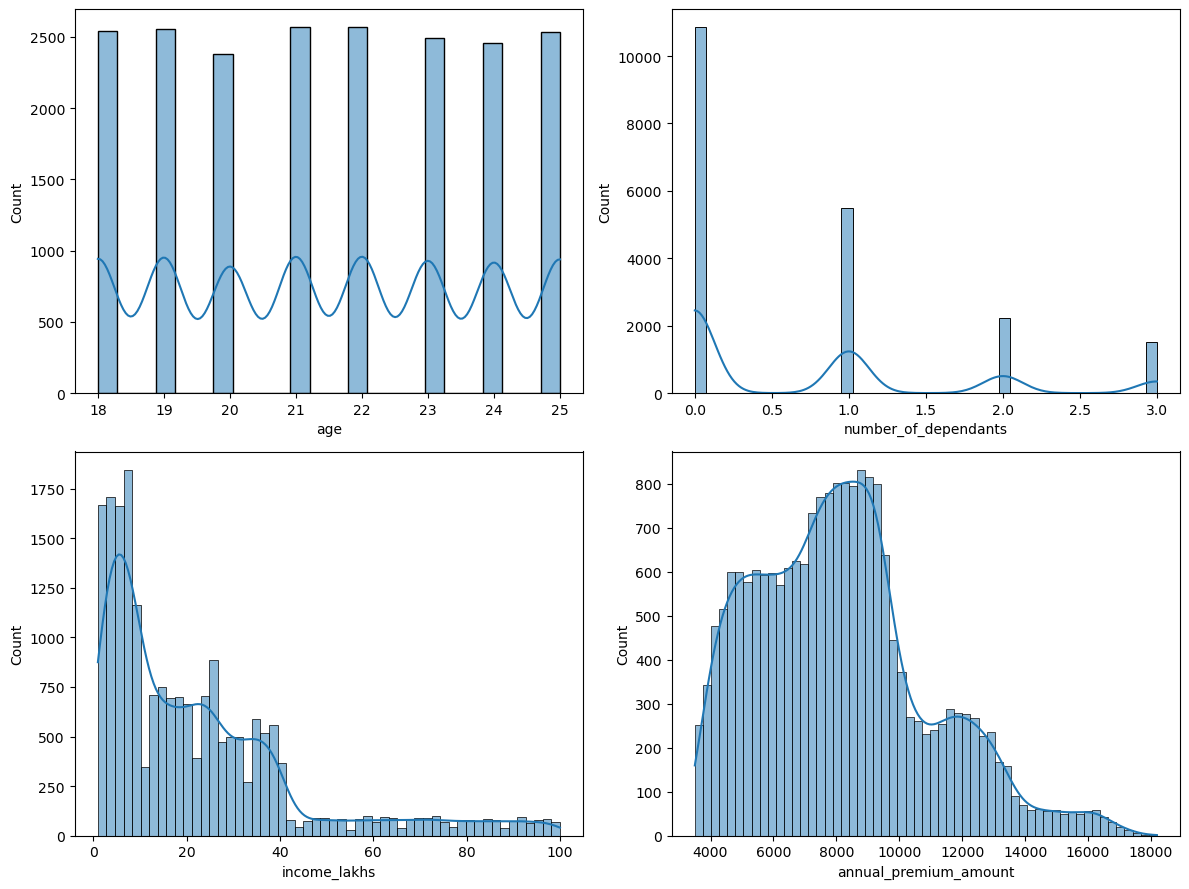

In [27]:
plt.figure(figsize=(12,9))
for i,col in enumerate(numeric_columns):
    plt.subplot(2,2,i+1)
    sns.histplot(x=df2[col],kde=True)
plt.tight_layout()
plt.show()

### Bivariate Analysis:Numeric Columns

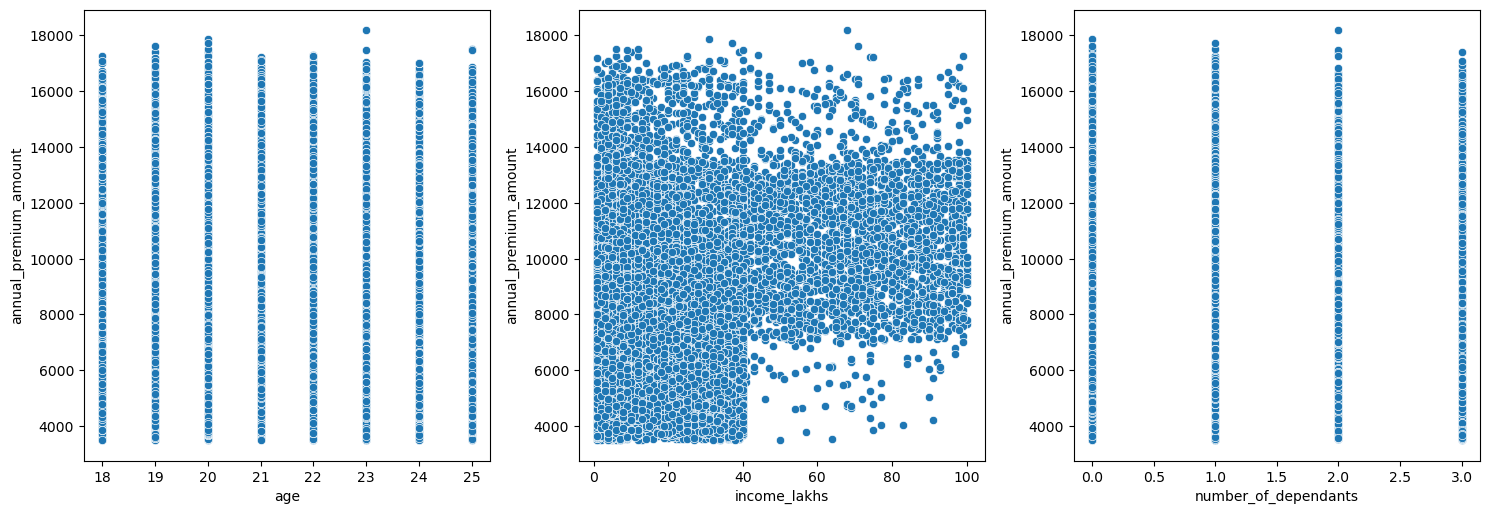

In [26]:
plt.figure(figsize=(15,15))
features = ["age", "income_lakhs", "number_of_dependants"]
for i,col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(df2,x=col,y="annual_premium_amount")
plt.tight_layout()
plt.show()

### Categorical Columns Analysis

In [28]:
categorical_col=df.select_dtypes(include=["object","category"]).columns
categorical_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [29]:
for col in categorical_col:
    print(col,":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


smoking_status : ['No Smoking' 'Smoking=0' 'Does Not Smoke' 'Not Smoking'] - here we can see an invalid category "Smoking=0". 

No Smoking, Smoking=0, Does Not Smoke, Not Smoking is all the same which is does not smoke.

In [30]:
df2["smoking_status"]=df2["smoking_status"].replace({
    'Smoking=0':"No Smoking",
    'Does Not Smoke':"No Smoking",
    'Not Smoking':'No Smoking'
})
df2.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

<h2 align="center">⚙️ Feature Engineering</h2>

In [31]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050


In [32]:
df2.shape

(20086, 13)

In [33]:
df2.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

### Calculate Risk Score

In [34]:
risk_scores={
    "diabetes":6,
    "heart disease":8,
    "high blood pressure":6,
    "thyroid":5,
    "no disease":0,
    "none":0
}

df2[["disease 1","disease 2"]]=df2["medical_history"].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,None
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,None
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,no disease,None
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,no disease,None
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,no disease,None


In [36]:
df2["disease 1"]=df2["disease 1"].fillna("none")
df2["disease 2"]=df2["disease 2"].fillna("none")

#Create a new column for total risk
df2["total_risk_score"]=0

#Convert diseases to risk scores
for disease in ["disease 1","disease 2"]:
    df2["total_risk_score"]+=df2[disease].map(risk_scores)    


### Normalisng Risk Score 

In [37]:
max_score=df2["total_risk_score"].max()
min_score=df2["total_risk_score"].min()
df2["normalised_risk_score"]=(df2["total_risk_score"] - min_score) / (max_score - min_score)
df2.head(10)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2,total_risk_score,normalised_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,no disease,none,0,0.000000
5,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,25L - 40L,30,High blood pressure,Gold,15473,high blood pressure,none,6,0.428571
6,19,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,8,No Disease,Bronze,4097,no disease,none,0,0.000000
7,18,Female,Northwest,Unmarried,1,Underweight,No Smoking,Salaried,<10L,5,Diabetes & High blood pressure,Bronze,8187,diabetes,high blood pressure,12,0.857143
8,23,Male,Northwest,Unmarried,0,Underweight,No Smoking,Salaried,<10L,8,No Disease,Bronze,5387,no disease,none,0,0.000000
9,20,Female,Northeast,Unmarried,0,Normal,Occasional,Salaried,10L - 25L,18,No Disease,Bronze,8866,no disease,none,0,0.000000


### Ordinal encoding for ordered categories

#### Insurance Plan

In [38]:
df2["insurance_plan"]=df2["insurance_plan"].map({
    "Bronze":1,
    "Silver":2,
    "Gold":3
})

#### Income Level

In [39]:
df2.income_level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [40]:
df2["income_level"]=df2["income_level"].map({
    '<10L':1,
    "10L - 25L":2,
    "25L - 40L":3,
    "> 40L":4,
    
})

### One-hot encoding for nominal features

In [42]:
nominal_cols=["gender","region","marital_status","bmi_category","smoking_status","employment_status"]
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,no disease,none,0,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,no disease,none,0,...,1,0,1,0,1,0,0,0,0,0


## Feature Selection

In [43]:
df4=df3.drop(columns=["medical_history","disease 1","disease 2","total_risk_score"])
df4

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,0,4,91,3,11603,0.000000,0,0,1,0,1,0,0,1,0,0,0,0
20092,23,0,4,57,3,14498,0.428571,0,1,0,0,1,1,0,0,1,0,0,0
20093,24,0,3,35,1,9111,0.000000,0,1,0,0,1,0,0,1,0,0,0,1
20094,21,0,3,32,1,8564,0.000000,1,1,0,0,1,0,0,0,0,1,0,0


## 📊 Correlation Analysis

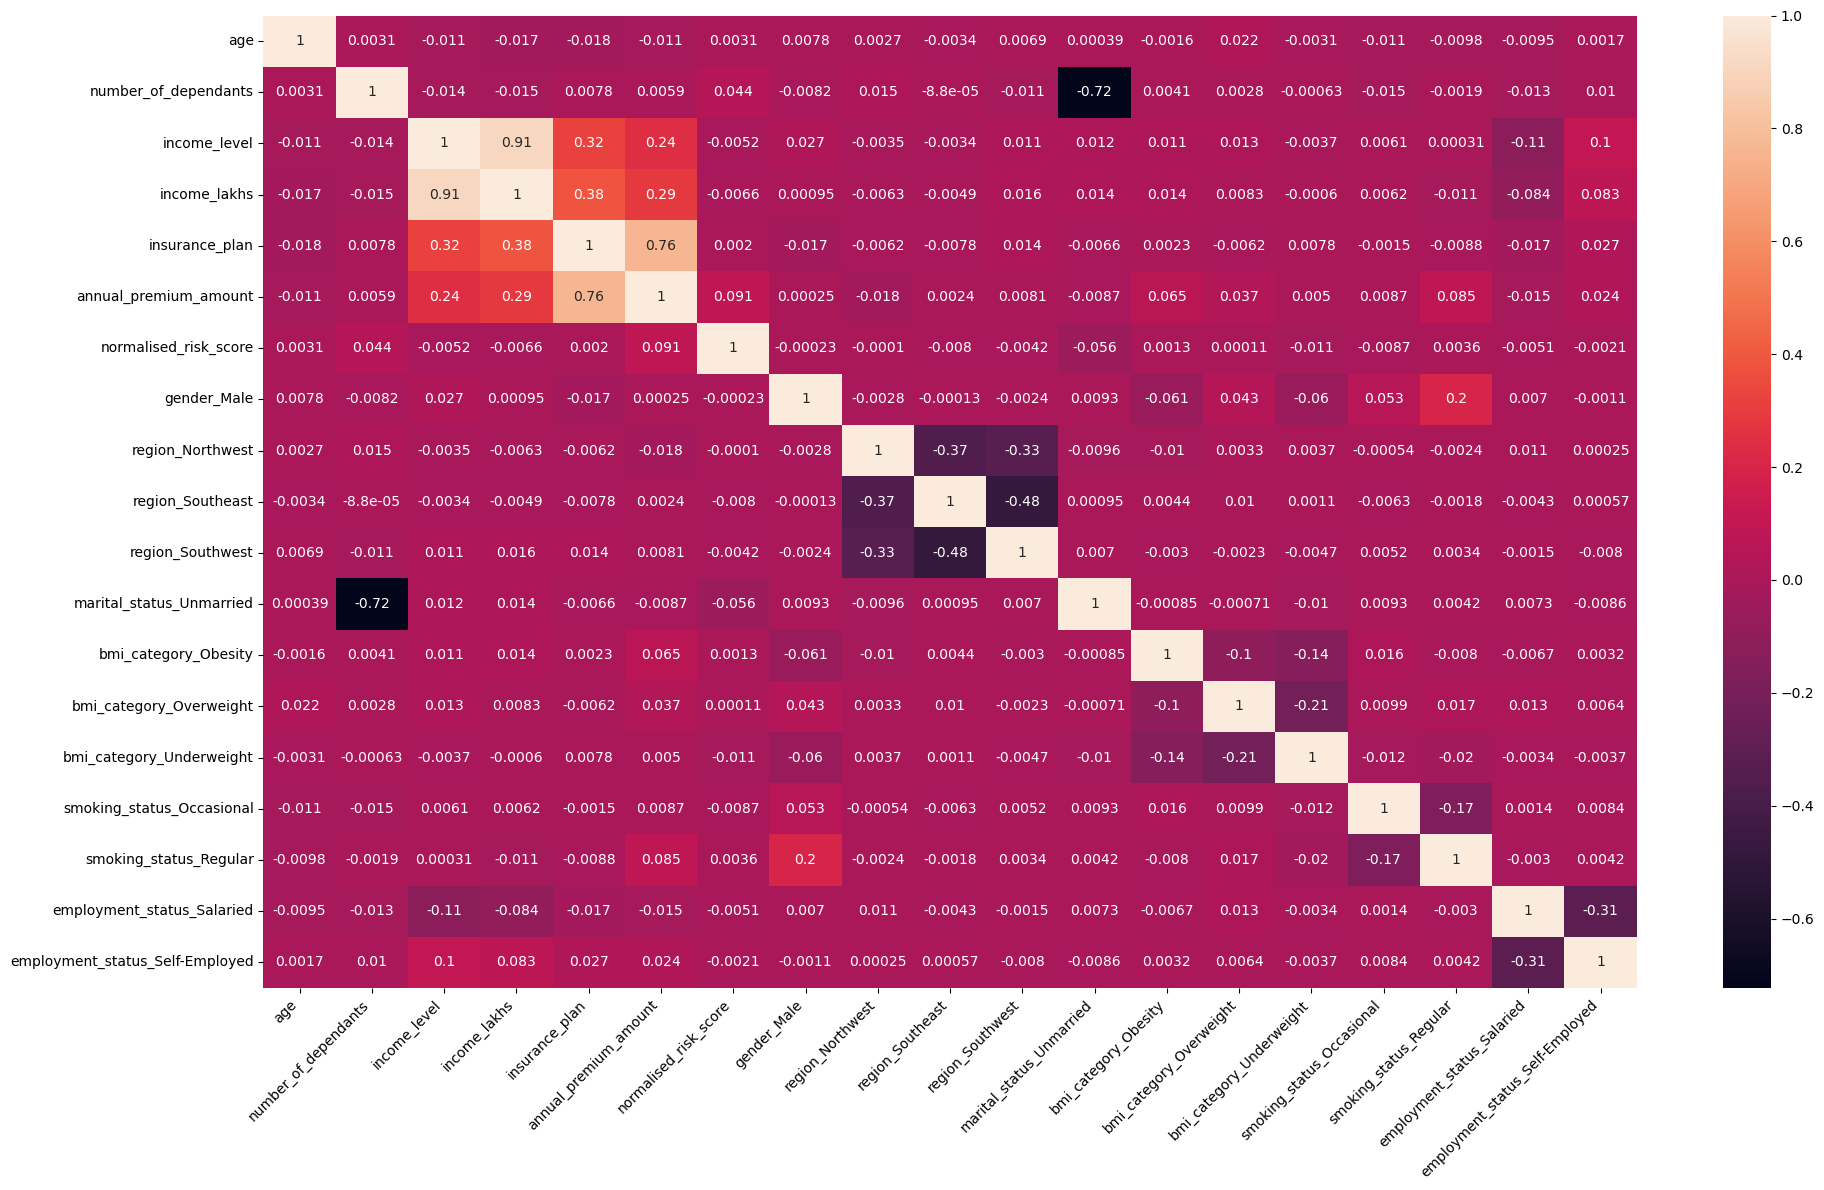

In [44]:
cm=df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Scaling Numerical Columns

In [45]:
X=df4.drop("annual_premium_amount",axis=1)
y=df4["annual_premium_amount"]

cols_to_scale=["age","number_of_dependants","income_lakhs","income_level","insurance_plan"]
scaler=MinMaxScaler()

X[cols_to_scale]=scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


### Feature Selection using VIF

VIF (Variance Inflation Factor) is used to detect multicollinearity.

Even within this segment, feature relationships may differ, 
so VIF is applied again to ensure model stability.

In [46]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df["Columns"]=data.columns
    vif_df["VIF"]=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [47]:
calculate_vif(X)

,Columns,VIF
0,age,3.142881
1,number_of_dependants,1.860761
2,income_level,11.928707
3,income_lakhs,11.874242
4,insurance_plan,1.592892
5,normalised_risk_score,1.154223
6,gender_Male,2.310023
7,region_Northwest,2.147701
8,region_Southeast,2.970188
9,region_Southwest,2.730503


In [48]:
calculate_vif(X.drop("income_level",axis=1))

,Columns,VIF
0,age,3.141534
1,number_of_dependants,1.858110
2,income_lakhs,2.291873
3,insurance_plan,1.587794
4,normalised_risk_score,1.154174
5,gender_Male,2.299848
6,region_Northwest,2.146767
7,region_Southeast,2.968993
8,region_Southwest,2.729813
9,marital_status_Unmarried,7.299818


Now VIF is less than 10 for all columns

In [50]:
X_reduced=X.drop("income_level",axis=1)


<h2 align="center"> Model Training</h2>

### Model Selection

The following models are used:

- Linear Regression → baseline interpretable model
- XGBoost → captures non-linear relationships

In [51]:
X_train,x_test,y_train,y_test=train_test_split(X_reduced,y,test_size=0.3,random_state=10)

In [52]:
X_train.shape

(14060, 17)

In [53]:
x_test.shape

(6026, 17)

### Linear Regression

In [54]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
train_score=model_lr.score(X_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.6020471274164894, 0.6047589163893645)

In [56]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([  55.190515, -145.039643,  -36.066768, 7000.070416, 1111.278786,
          9.825648, -114.27345 ,  -36.466371,  -67.223225,  -58.534342,
        792.95266 ,  435.760406,  169.728916,  244.813937,  619.082947,
        -13.053549,   -4.342722])

In [57]:
feature_importances=model_lr.coef_

In [58]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

,Coefficients
number_of_dependants,-145.039643
region_Northwest,-114.273450
region_Southwest,-67.223225
marital_status_Unmarried,-58.534342
region_Southeast,-36.466371
income_lakhs,-36.066768
employment_status_Salaried,-13.053549
employment_status_Self-Employed,-4.342722
gender_Male,9.825648
age,55.190515


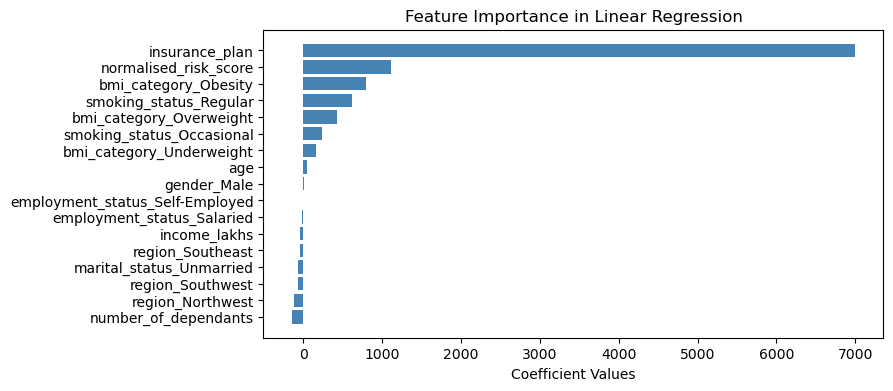

In [59]:
plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in Linear Regression")
plt.show()

### XGBoost

In [68]:
model_xgb=XGBRegressor()
model_xgb.fit(X_train,y_train)
model_xgb.score(x_test,y_test)

0.5638787746429443

with xgboost we got accuracy of 56%

### Random Search CV

In [62]:
model_xgb=XGBRegressor()

param_grid={
    'n_estimators':[20,40,50],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}

random_search=RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_

0.5997088948885599

In [63]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}

<h2> Model Evaluation</h2>

| Model                |R2|
|:---------------------|:----:| 
|Linear               |0.60|
|XGBoost              |0.56|
|XGBoost Random Search |0.60|

### Insight

- Linear Regression and tuned XGBoost achieved similar performance (R² ≈ 0.60)
- The marginal difference between simple and complex models suggests that increasing model complexity does not significantly improve predictive performance
- This indicates that the current feature set captures only a limited portion of the variance in the target variable


<h1 align="center"> Error Analysis</h1>

In [65]:
best_model = model_lr

In [66]:
y_pred=best_model.predict(x_test)

residuals=y_pred-y_test
residuals_pct=residuals*100/y_test

results_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})

results_df.head()

,actual,predicted,diff,diff_pct
12774,6238,6625.420564,387.420564,6.210653
14758,9462,7117.148903,-2344.851097,-24.781770
13205,5152,7052.316369,1900.316369,36.885023
14278,6988,7924.504344,936.504344,13.401608
19351,4917,6696.274716,1779.274716,36.186185


<Axes: xlabel='diff_pct', ylabel='Count'>

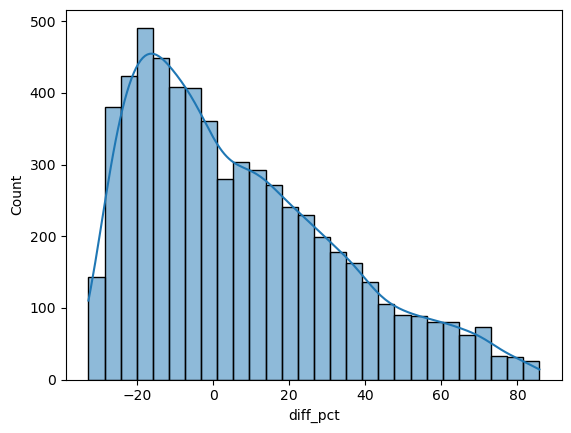

In [67]:
sns.histplot(results_df["diff_pct"],kde=True)

### Error Distribution Insight

- The model shows a skewed error distribution with a tendency to underpredict premiums
- Presence of extreme errors (up to ~80%) indicates that the model is still failing for certain observations
- Segmentation alone did not fully resolve prediction instability

In [69]:
extreme_error_threshold=10
extreme_results_df=results_df[np.abs(results_df["diff_pct"])>extreme_error_threshold]
extreme_results_df.shape

(4404, 4)

In [71]:
(extreme_results_df.shape[0]*100)/results_df.shape[0]

73.08330567540658

We have 73% extreme errors. We need to handle them

In [72]:
extreme_results_df.index

Index([14758, 13205, 14278, 19351, 10622, 14799, 16348,  5573,  5634, 14882,
       ...
       10266,  5484,  8988,  9658,  1365,   399, 17652,  5807, 10298, 13316],
      dtype='int64', length=4404)

In [73]:
extreme_error_df=x_test.loc[extreme_results_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
14758,0.285714,0.000000,0.060606,0.0,0.000000,0,0,0,1,1,0,0,0,0,1,0,1
13205,0.714286,0.333333,0.141414,0.0,0.000000,1,1,0,0,1,0,0,0,0,1,0,1
14278,0.714286,0.333333,0.222222,0.0,0.000000,1,0,1,0,1,1,0,0,0,1,0,0
19351,0.571429,0.000000,0.101010,0.0,0.000000,1,0,0,1,1,0,0,1,0,0,0,0
10622,0.428571,0.333333,0.050505,0.0,0.357143,0,0,1,0,1,0,1,0,0,0,0,0


## Residual Plot

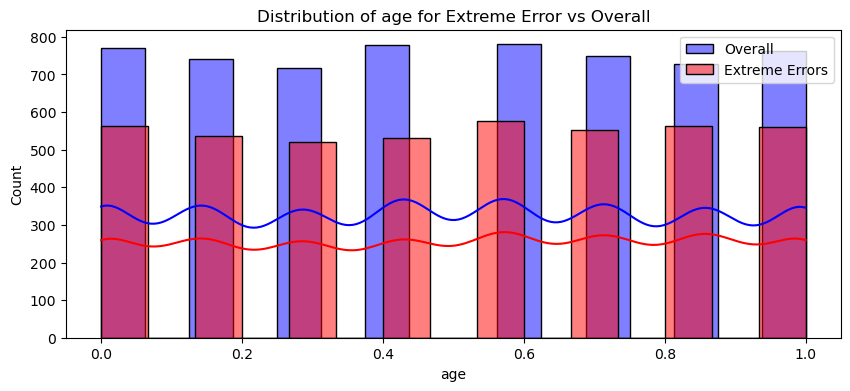

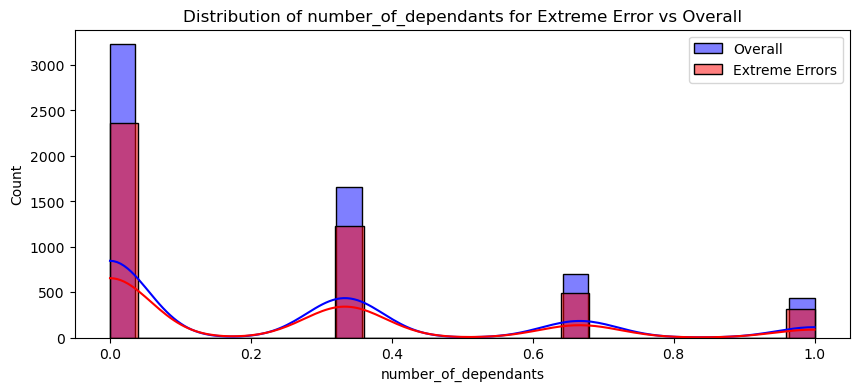

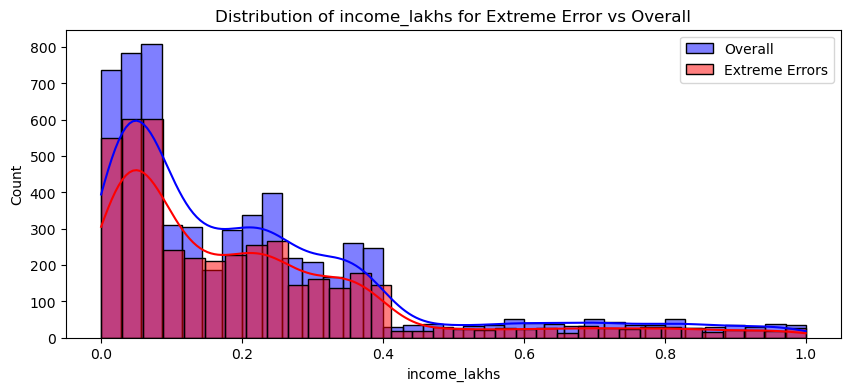

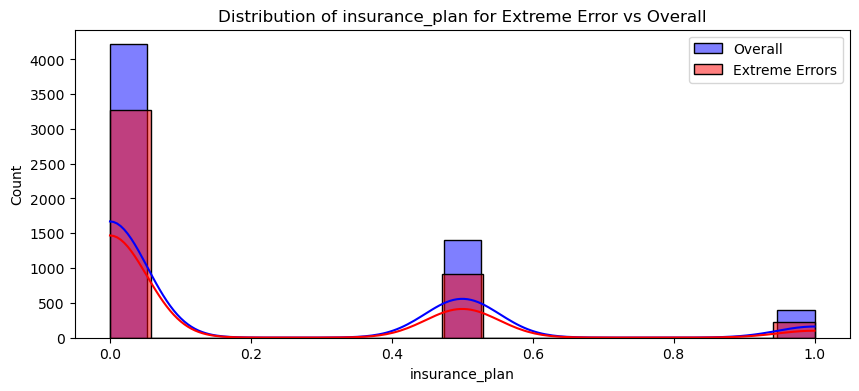

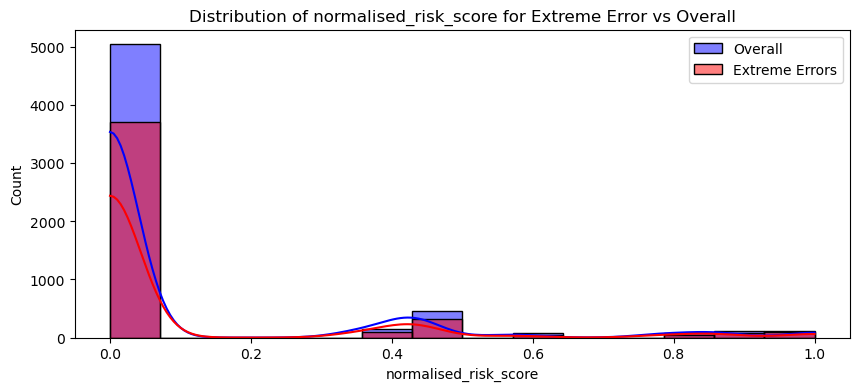

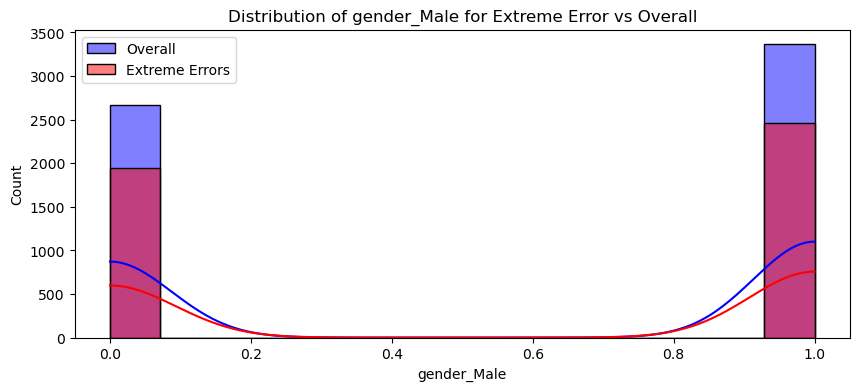

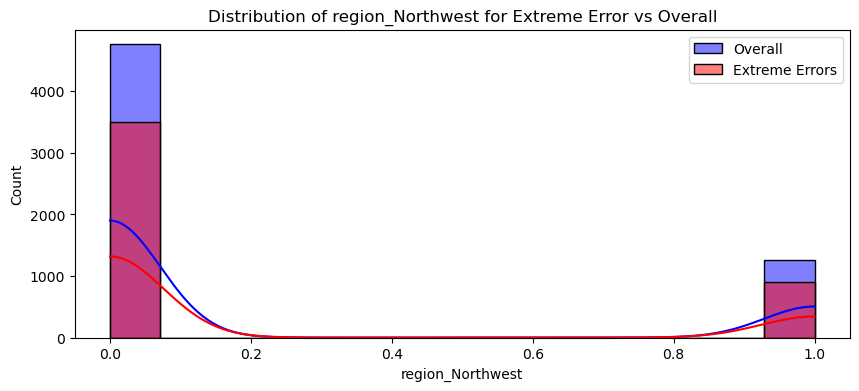

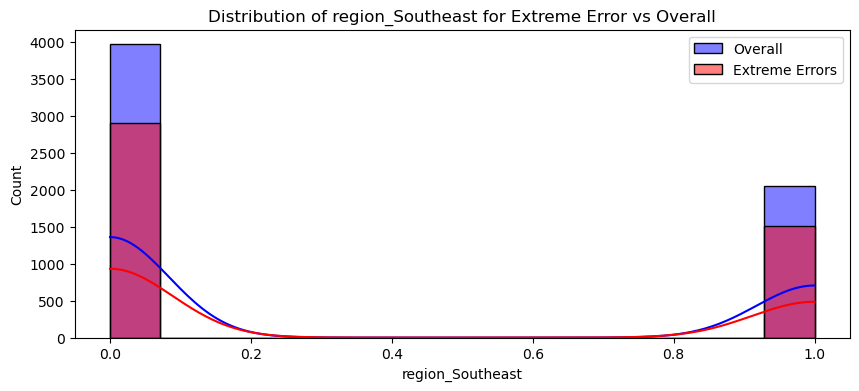

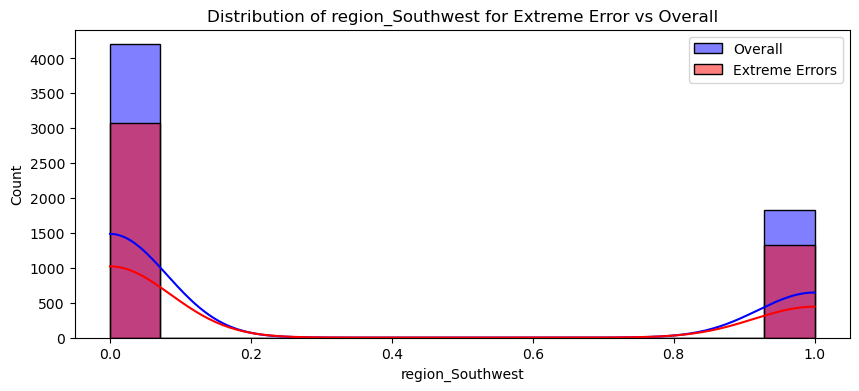

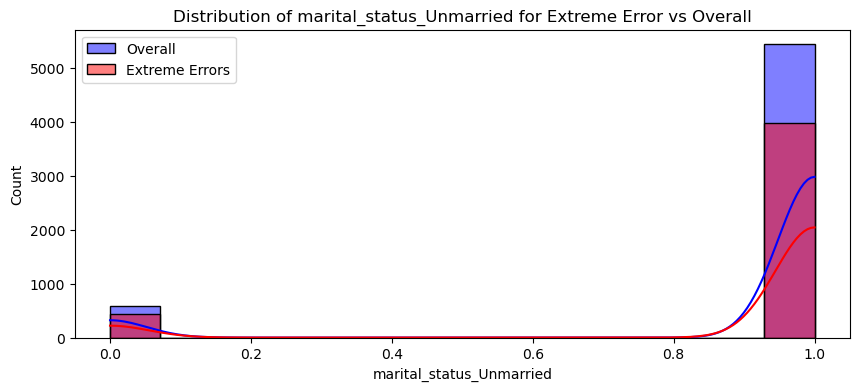

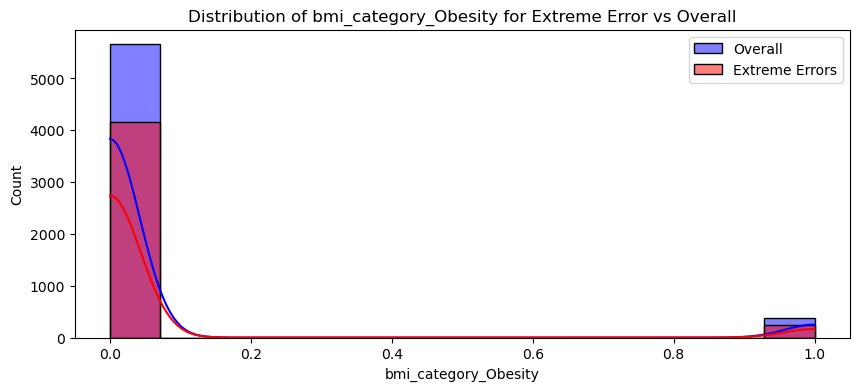

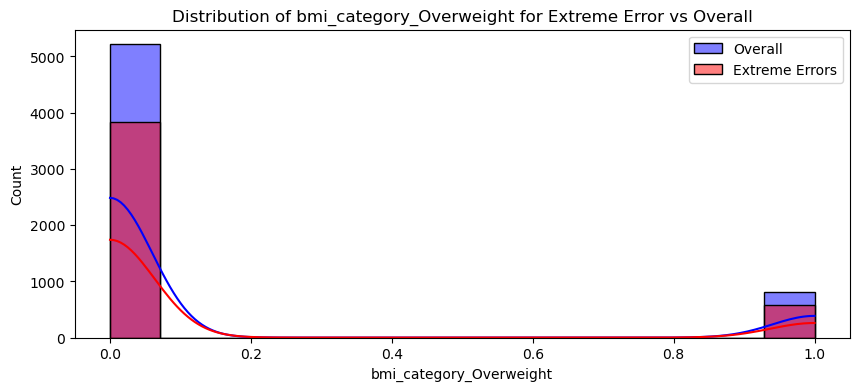

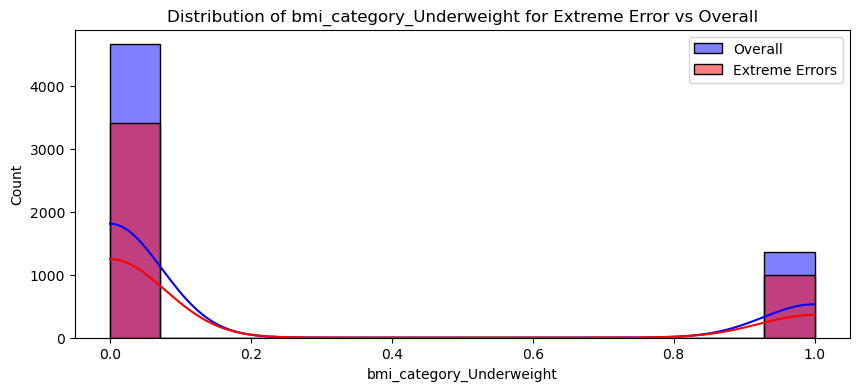

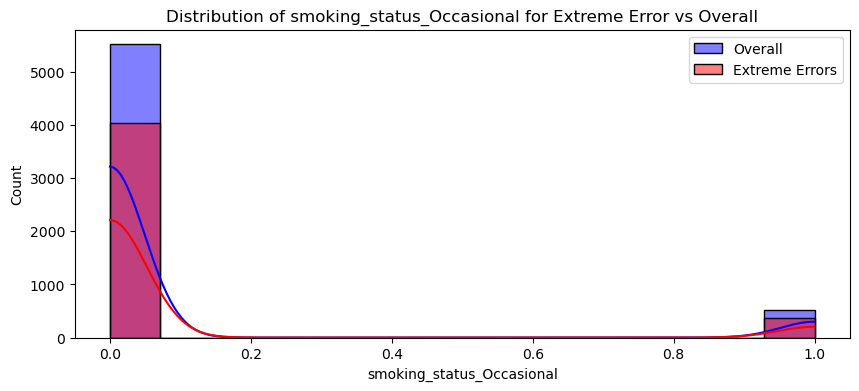

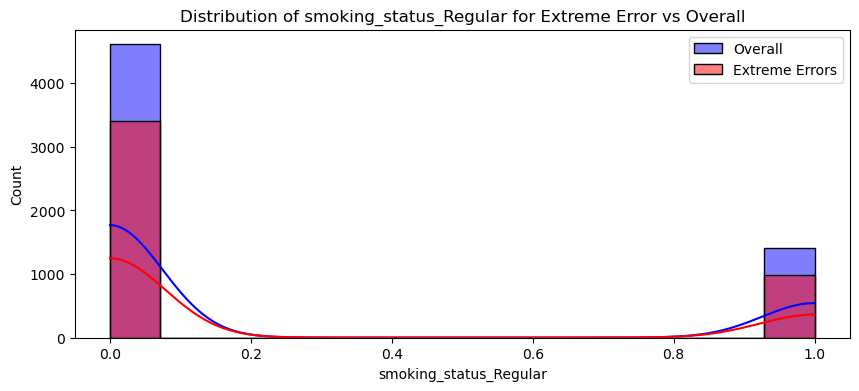

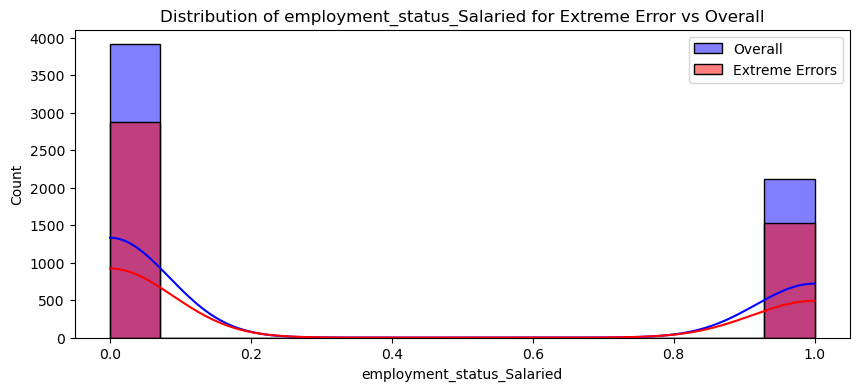

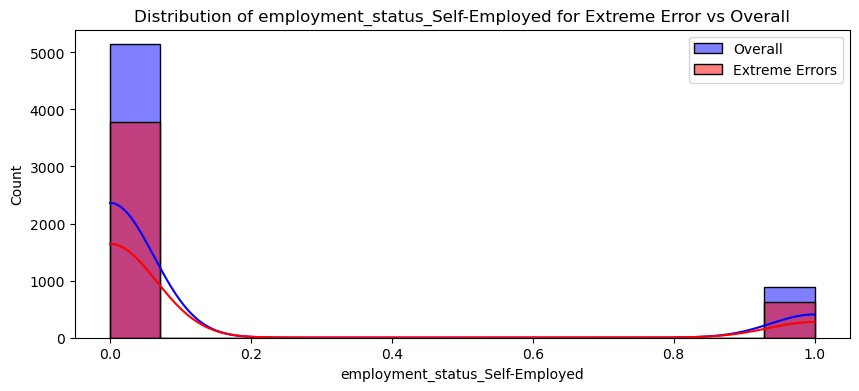

In [75]:
for feature in x_test.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(x_test[feature],label="Overall",kde=True,color="blue",alpha=0.5)
    sns.histplot(extreme_error_df[feature],label="Extreme Errors",kde=True,color="Red")
    plt.legend()
    plt.title(f"Distribution of {feature} for Extreme Error vs Overall")
    plt.show()

### Feature-Level Error Analysis

- No clear pattern observed between age and extreme errors
- Extreme errors are spread across categories
- Indicates that errors are not driven by a single feature

## Conclusion on Segmentation

Although age-based segmentation was introduced to improve model performance, 
error analysis shows that extreme prediction errors are not concentrated within specific age groups.

This suggests:
- Age is not the primary factor driving prediction errors
- The model may be missing important features
- Existing features may not fully capture underlying risk factors
- Model is limited by available data

Therefore, segmentation alone is insufficient to fully resolve prediction inaccuracies.

## Next Steps

To improve model performance:

- Advanced Feature Engineering:
  - Interaction features (age × risk score, income × health)
  - Non-linear transformations

- Additional Data:
  - Detailed medical records
  - Lifestyle indicators
  - Claims history

- Model Enhancements:
  - Ensemble methods
  - More complex architectures